# Modeling 


In [ ]:
import sys
sys.path.insert(0, '../src')
# path to save models
MODEL_DIR = os.path.join(os.path.dirname(__file__), '..', 'models')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
from catboost import CatBoostRegressor
import joblib, os
import preprocess
import explore
import model

In [ ]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im)
df_cl_vis   = preprocess.clean_cl(df_cl)

# Immunological: drop >25% NaN columns, remove confirmed outliers
_im_nan_frac = df_im_vis.drop(columns=_im_id_cols).isna().mean()
_im_high_nan = _im_nan_frac[_im_nan_frac > 0.25].index.tolist()
df_im_mod    = df_im_vis.drop(columns=_im_high_nan)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod)

# Clinical: drop >25% NaN columns
_cl_id_cols  = ['Patient', 'Timepoint', 'date', 'measurement_timepoint']
_cl_nan_frac = df_cl_vis.drop(columns=_cl_id_cols).isna().mean()
_cl_high_nan = _cl_nan_frac[_cl_nan_frac > 0.25].index.tolist()
df_cl_mod    = df_cl_vis.drop(columns=_cl_high_nan)

print(f"df_im_mod : {df_im_mod.shape}")
print(f"df_cl_mod : {df_cl_mod.shape}")


  [1] Dropping excluded columns and renaming Messdatum → Date
  Dropping 44 columns.
  [2] Dropping known empty rows
  Dropping 7 rows at index: [823, 824, 825, 826, 827, 828, 78]
  Patient IDs in dropped rows: [30.0]
  Unique patients remaining: 264
  [3] Replacing German NaN markers
  Neu_CD25+: replaced 161 null markers
  BAS_CD25+: replaced 18 null markers
  Mo_CD25+: replaced 109 null markers
  T_CD25hi: replaced 5 null markers
  TC_CD25hi: replaced 790 null markers
  TH_CD25hi: replaced 5 null markers
  B_CD25+: replaced 7 null markers
  B_CD25hi: replaced 810 null markers
  NK_CD25+: replaced 150 null markers
  Neu_HLADR+: replaced 27 null markers
  Eos_HLADR+: replaced 567 null markers
  Mo_HLADRhi: replaced 4 null markers
  Mo2_HLADR+: replaced 192 null markers
  Mo3_HLADR+: replaced 73 null markers
  Mo1_HLADRhi: replaced 11 null markers
  Mo2_HLADRhi: replaced 230 null markers
  Mo3_HLADRhi: replaced 90 null markers
  TC_HLADR+: replaced 7 null markers
  T_HLADRhi: replaced 


  Targets: 'pain_scale'  (T1 → T2)
  Patients with T1 values    : 189
  Patients with T2 values    : 176
  Eligible (non-NaN both, n)    : 142
  Eligible patient IDs          : [1, 5, 6, 10, 12, 15, 16, 17, 18, 19, 20, 21, 22, 23, 29, 34, 58, 72, 76, 91, 92, 93, 94, 101, 104, 105, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 123, 125, 126, 127, 128, 129, 131, 132, 133, 134, 135, 136, 137, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 151, 153, 154, 155, 157, 158, 159, 161, 163, 164, 170, 171, 172, 173, 174, 175, 176, 177, 178, 180, 181, 182, 183, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 199, 201, 202, 203, 205, 206, 207, 208, 209, 210, 212, 214, 215, 218, 220, 221, 222, 223, 224, 225, 226, 229, 230, 232, 234, 237, 239, 240, 245, 246, 248, 250, 253, 256, 258, 259, 269, 270, 271, 272, 273]

  Target distributions:
    pain_reduction                              mean=1.349  std=2.042  [-4.000, 7.100]
    pain_reduction_pct   

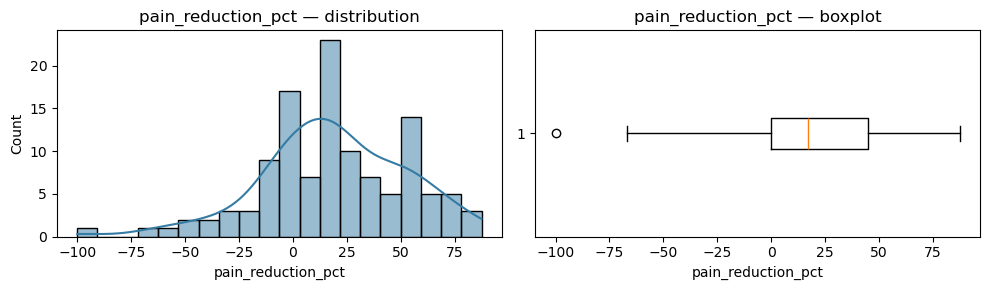

  Top 10 Pearson |r| with pain_reduction_pct:
pain_reduction             0.934507
TC eff_PD1+_t1_minus_t2    0.185795
DPT_t1_minus_t2            0.178147
pain_scale_t1              0.177349
TC_PD1+_t1_minus_t2        0.171555
TC CM_PD1+_t1_minus_t2     0.161279
TH_t1_minus_t2             0.155935
Basophils.1_t1_minus_t2    0.153092
T cells_t1_minus_t2        0.152862
Monocytes_t1_minus_t2      0.151674

───────────────────────────────────────────────────────
  pain_under_load_reduction  (n=117, features=96)
  mean=0.52  std=0.75  min=-1.00  max=3.00
  skew=1.02  kurt=1.00  zeros=54.7%


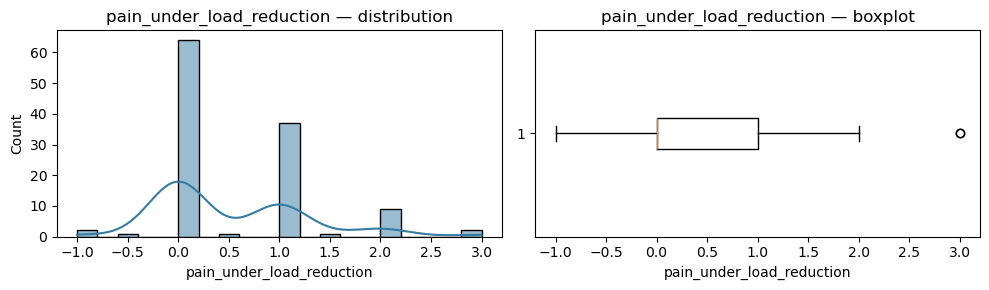

  Top 10 Pearson |r| with pain_under_load_reduction:
pain_under_load_reduction_pct    0.982386
NK_CD25+_t1_minus_t2             0.244959
BAS_CD25+_t1_minus_t2            0.243665
Mo1_t1_minus_t2                  0.210402
Monocytes_t1_minus_t2            0.207577
NK2_t1_minus_t2                  0.193114
pain_under_load_t1               0.190102
Neu_HLADR+_t1_minus_t2           0.187514
B_CD25+_t1_minus_t2              0.160346
DNT_t1_minus_t2                  0.142525


In [ ]:
# Constructing targets and plotting distributions:

print('\nConstructing regression targets from clinical data')
pain_targets       = model.construct_datasets_targets(df_cl_mod, 'pain_scale',      [1, 2])
targets_under_load = model.construct_datasets_targets(df_cl_mod, 'pain_under_load', [1, 2])


# Collect all reduction_pct columns across all target DataFrames for plotting
target_frames = {
    'pain_scale':      pain_targets,
    'pain_under_load': targets_under_load,
}

fig, axes = plt.subplots(2, len(target_frames), figsize=(5 * len(target_frames), 8))
colors = sns.color_palette('mako', len(target_frames))

for col_idx, (name, tdf) in enumerate(target_frames.items()):
    prefix  = name.replace('_scale', '')   # matches construct_datasets_targets naming
    red_col = f'{prefix}_reduction'
    pct_col = f'{prefix}_reduction_pct'

    # Absolute reduction
    ax0 = axes[0, col_idx]
    sns.histplot(tdf[red_col].dropna(), kde=True, ax=ax0,
                 color=colors[col_idx], bins=20)
    ax0.set_title(f'{name}\nAbsolute reduction (T1−T2)')
    ax0.set_xlabel('Reduction')

    # Percent reduction
    ax1 = axes[1, col_idx]
    sns.histplot(tdf[pct_col].dropna(), kde=True, ax=ax1,
                 color=colors[col_idx], bins=20)
    ax1.set_title(f'{name}\nPercent reduction (%)')
    ax1.set_xlabel('Reduction (%)')

plt.suptitle('Target Distributions (T1 - T2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
# Visualizing power-transformed target distributions (on copies)

fig, axes = plt.subplots(2, len(target_frames), figsize=(5 * len(target_frames), 8))
colors = sns.color_palette('mako', len(target_frames))

for col_idx, (name, tdf) in enumerate(target_frames.items()):
    prefix  = name.replace('_scale', '')
    red_col = f'{prefix}_reduction'
    pct_col = f'{prefix}_reduction_pct'

    tdf_viz = tdf[[red_col, pct_col]].copy()
    pt_viz  = PowerTransformer(method='yeo-johnson', standardize=True)
    tdf_viz[[red_col, pct_col]] = pt_viz.fit_transform(tdf_viz)

    ax0 = axes[0, col_idx]
    sns.histplot(tdf_viz[red_col].dropna(), kde=True, ax=ax0,
                 color=colors[col_idx], bins=20)
    ax0.set_title(f'{name}\nAbsolute reduction (T1−T2) — transformed')
    ax0.set_xlabel('Reduction (transformed)')

    ax1 = axes[1, col_idx]
    sns.histplot(tdf_viz[pct_col].dropna(), kde=True, ax=ax1,
                 color=colors[col_idx], bins=20)
    ax1.set_title(f'{name}\nPercent reduction (%) — transformed')
    ax1.set_xlabel('Reduction (%) (transformed)')

plt.suptitle('Target Distributions after Power Transform (T1 - T2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Dataset Overview

In [ ]:
print('\nConstructing datasets for modeling:')

model_datasets = {}
for tgt, tdf in target_frames.items():
    model_datasets[tgt] = model.create_model_datasets(
        df_cl_mod, df_im_mod, tdf, timepoints=[1, 2]
    )

# pain_reduction_pct is placed in the same dataset as pain_reduction
model_datasets['pain_reduction_pct'] = model_datasets['pain_reduction']

# displaying combined datasets:
TableReport(model_datasets['pain_reduction_pct'], max_plot_columns=180)
TableReport(model_datasets['pain_under_load_reduction'], max_plot_columns=180)

# Correlation between target and features:
print(f"\n{'─'*55}")
print("  Feature–target Pearson correlations (top 10, combined dataset):")
for tgt, df_comb in model_datasets.items():
    id_like = ['Patient', 'Timepoint']
    num_cols = [c for c in df_comb.select_dtypes(include='float64').columns
                if c not in id_like]
    corrs = df_comb[num_cols].corrwith(df_comb[tgt]).drop(index=tgt, errors='ignore')
    corrs = corrs.dropna().abs().sort_values(ascending=False).head(20)
    print(f"\n  {tgt}:")
    print(corrs.to_string())


  Dataset : pain_reduction
  Target  : pain_reduction_pct   |   Baseline feature : pain_scale_t1
  Shape   : (118, 96)   |   Patients : 118
  OK: both target and baseline-pain column present


Processing column  96 / 96


<TableReport: use .open() to display>


  Dataset : pain_under_load_reduction
  Target  : pain_under_load_reduction   |   Baseline feature : pain_under_load_t1
  Shape   : (117, 96)   |   Patients : 117
  OK: both target and baseline-pain column present


Processing column  96 / 96


<TableReport: use .open() to display>

## Baseline CatBoost

In [ ]:

print('\n Running baseline CatBoost — pain_reduction, pain_reduction_pct, pain_under_load_reduction')

_pt = PowerTransformer(method='yeo-johnson', standardize=True)

baseline_results = {}
for tgt, df_comb in model_datasets.items():
    res_comb, mdl_comb, X_comb, ypred_comb = model.run_catboost_regressor(
        df_comb, tgt, 'Combined T1−T2 diff', target_transformer=_pt)
    baseline_results[tgt] = (res_comb, mdl_comb, X_comb, ypred_comb)

for tgt, (res, *_) in baseline_results.items():
    model.print_regression_summary({'Combined': res}, tgt)

    


  CatBoost Regressor Baseline — Baseline — pain_reduction_pct
  Target : pain_reduction_pct
  Samples: 118,  Features: 93
  CV     : 5-fold × 5 repeats = 25 fits
  Fold  1: MAE=36.814  MSE=1969.601  RMSE=44.380  R²=-0.261
  Fold  2: MAE=25.548  MSE=903.718  RMSE=30.062  R²=-0.245
  Fold  3: MAE=21.024  MSE=760.735  RMSE=27.581  R²=-0.001
  Fold  4: MAE=32.521  MSE=1863.222  RMSE=43.165  R²=-0.508
  Fold  5: MAE=22.980  MSE=907.074  RMSE=30.118  R²=-0.211
  Fold  6: MAE=32.043  MSE=1857.441  RMSE=43.098  R²=-0.234
  Fold  7: MAE=31.371  MSE=1581.460  RMSE=39.768  R²=-0.263
  Fold  8: MAE=28.163  MSE=1226.816  RMSE=35.026  R²=-0.187
  Fold  9: MAE=23.382  MSE=835.151  RMSE=28.899  R²=0.045
  Fold 10: MAE=24.644  MSE=1086.288  RMSE=32.959  R²=-0.594
  Fold 11: MAE=26.283  MSE=963.727  RMSE=31.044  R²=-0.206
  Fold 12: MAE=21.924  MSE=825.337  RMSE=28.729  R²=-0.008
  Fold 13: MAE=39.003  MSE=2336.748  RMSE=48.340  R²=-0.316
  Fold 14: MAE=24.033  MSE=1056.747  RMSE=32.508  R²=-0.157
  Fo

## CatBoost Model - RENT, Nested CV + Optuna Hyperparameter Tuning

### Target: pain_reduction 

In [ ]:
MODEL_DIR = os.path.join(os.path.dirname(__file__), '..', 'models')

print('\n1.1: CatBoost (Nested CV + RENT + Optuna) — pain_reduction (T1-T2)')

cb_red_results, cb_red_model, cb_red_X, cb_red_ypred, cb_red_features, cb_red_rent_params = \
    model.run_advanced_catboost_rent(
        model_datasets['pain_reduction'],
        target_col='pain_reduction',
        target_transformer=_pt,
    )

# Save model and feature matrix to run SHAP
cb_red_model.save_model(os.path.join(MODEL_DIR, 'cb_red_model.cbm'))
joblib.dump(cb_red_X, os.path.join(MODEL_DIR, 'cb_red_X.pkl'))
print(' Saved Catboost model (pain_reduction target) cb_red_model.cbm and cb_red_X.pkl to', os.path.abspath(MODEL_DIR))


In [ ]:
# Shap on saved model 
cb_red_model = CatBoostRegressor()
cb_red_model.load_model(os.path.join(MODEL_DIR, 'cb_red_model.cbm'))
cb_red_X = joblib.load(os.path.join(MODEL_DIR, 'cb_red_X.pkl'))

print('\n SHAP — CatBoost (pain_reduction, T1→T2)')
cb_red_shap = model.plot_shap_regressor(
    cb_red_model, cb_red_X, 'CatBoost — pain_reduction (T1→T2)')


### Target: pain_reduction_pct

In [ ]:

print('\n1.2: CatBoost (Nested CV + RENT + Optuna) — pain_reduction_pct (T1-T2)')

cb_pct_results, cb_pct_model, cb_pct_X, cb_pct_ypred, cb_pct_features, cb_pct_rent_params = \
    model.run_advanced_catboost_rent(
        model_datasets['pain_reduction_pct'],
        target_col='pain_reduction_pct',
        target_transformer=_pt,
    )

# — Save model and feature matrix so SHAP can be run later without retraining —
cb_pct_model.save_model(os.path.join(MODEL_DIR, 'cb_pct_model.cbm'))
joblib.dump(cb_pct_X, os.path.join(MODEL_DIR, 'cb_pct_X.pkl'))
print(' Saved cb_pct_model.cbm and cb_pct_X.pkl to', os.path.abspath(MODEL_DIR))


In [ ]:
# SHAP plot on saved model
cb_pct_model = CatBoostRegressor()
cb_pct_model.load_model(os.path.join(MODEL_DIR, 'cb_pct_model.cbm'))
cb_pct_X = joblib.load(os.path.join(MODEL_DIR, 'cb_pct_X.pkl'))

print('\nSHAP — CatBoost (pain_reduction_pct, T1-T2)')
cb_pct_shap = model.plot_shap_regressor(
    cb_pct_model, cb_pct_X, 'CatBoost — pain_reduction_pct (T1-T2)')


### Target: pain_under_load_reduction

In [ ]:
print('\n1.3: CatBoost (Nested CV + RENT + Optuna) — pain_under_load_reduction (T1-T2)')

cb_ul_results, cb_ul_model, cb_ul_X, cb_ul_ypred, cb_ul_features, cb_ul_rent_params = \
    model.run_advanced_catboost_rent(
        model_datasets['pain_under_load_reduction'],
        target_col='pain_under_load_reduction',
        target_transformer=_pt,
    )

# Save model and feature matrix so SHAP can be run without retraining
cb_ul_model.save_model(os.path.join(MODEL_DIR, 'cb_ul_model.cbm'))
joblib.dump(cb_ul_X, os.path.join(MODEL_DIR, 'cb_ul_X.pkl'))
print(' Saved cb_ul_model.cbm and cb_ul_X.pkl to', os.path.abspath(MODEL_DIR))


In [ ]:
# SHAP plot on saved model
cb_ul_model = CatBoostRegressor()
cb_ul_model.load_model(os.path.join(MODEL_DIR, 'cb_ul_model.cbm'))
cb_ul_X = joblib.load(os.path.join(MODEL_DIR, 'cb_ul_X.pkl'))

print('\nSHAP — CatBoost (pain_under_load_reduction, T1-T2)')
cb_ul_shap = model.plot_shap_regressor(
    cb_ul_model, cb_ul_X, 'CatBoost — pain_under_load_reduction (T1-T2)')


## Model 2 - RENT, Nested CV + Optuna Hyperparameter Tuning

## Model 3 - RENT, Nested CV + Optuna Hyperparameter Tuning